[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-biology/AdvancesMSDataProcessing/blob/master/MultivariateExploratoryAnalysisSupervisedModelsClassificationPrediction/Stats_Untargeted_Metabolomics_python.ipynb)


# Performing basic uni- and multivariate statistical analsysis of untargeted metabolomics data

**Updated on:** 2024-02-17 17:33 CET

In this Jupyter Notebook we perform basic explorative uni- and multivariate statistical analyses of an untargeted metabolomics data set, including data cleaning steps, normalization and batch correction. **All step numbers in the Python Notebook correspond to those in the R Notebook to ensure consistency and comparability with the main protocol, which primarily uses the R Notebook.**

<div class="alert alert-block alert-info">

**Authors**: Abzer Kelminal (abzer.shah@uni-tuebingen.de), Francesco Russo (frru@ssi.dk), Filip Ottosson (faot@ssi.dk), Madaleine Ernst (maet@ssi.dk), Axel Walter (axel.walter@uni-tuebingen.de), Carolina Gonzalez (cgonzalez7@eafit.edu.co), Efi Kontou (eeko@biosustain.dtu.dk), Judith Boldt (judith.boldt@dsmz.de) <br>

**Input file format**: .csv files or .txt files <br>
**Outputs**: .csv files, .pdf & .svg images  <br>
**Dependencies**: pandas, numpy, glob, os, re, itertools, plotly, matplotlib, scipy, sklearn, pingouin, skbio, ipyfilechooser, ipywidgets, pynmranalysis, PyComplexHeatmap

The session info at the end of this notebook gives info about the versions of all the packages used here.
</div>

---
<font color = 'red' size =4>**Disclaimer**: This Notebook is compatible with both Jupyter Notebook and Google Colab. However, we advise users with a Windows OS to opt for the Colab version due to potential compatibility issues with certain modules when installed locally on Windows. </font>

## Package installation

### <font color ='darkblue'>Installing and loading necessary packages </font>
<a id = 'pkg_install'></a>
Before we start, we need to install all packages needed for our analyses and load the installed packages into our session.

In [ ]:
# Install libraries that are not preinstalled
!pip install pandas numpy plotly scikit-learn scikit-posthocs pingouin kaleido nbformat session_info PyComplexHeatmap yellowbrick matplotlib

In [ ]:
# importing necessary modules
import pandas as pd
import numpy as np

import glob
import os
import re
import itertools
import io
import session_info
import shutil
import warnings
import matplotlib.pyplot as plt
import platform
import math
import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.io as pio

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.spatial import distance
from scipy.stats import lognorm
from scipy.stats import shapiro
from scipy.stats import lognorm
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import pingouin as pg
import scikit_posthocs as sp
from PyComplexHeatmap import *
from yellowbrick.cluster import KElbowVisualizer

from PIL import Image

import statsmodels.api as sm

import time
from sklearn.inspection import permutation_importance

In [ ]:
# Get the operating system information
os_info = platform.system()

# Print the operating system
print(f"The operating system is: {os_info}")

The operating system is: Linux


<font color='red' size= 4 > Installing the following module is not a problem in Google Colab (as it is Linux-based) as well as in macOS and Linux-based systems.</font> scikit-bio is not supported for Windows OS.

In [ ]:
if os != "Windows":
    !pip install scikit-bio
    import skbio
    from skbio.stats.distance import permdisp
    print('You can compute PCoA and PERMANOVA')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 45.7 MB/s eta 0:00:00
You can compute PCoA and PERMANOVA


In [ ]:
# Disable warnings for cleaner output, comment out for debugging
warnings.filterwarnings('ignore')

---
# <font color ='blue'> Multivariate analysis </font>
<a name="multi"></a>

In [ ]:
md_Samples = pd.read_csv("Metadata_Samples.tsv", sep='\t', index_col=0)
md_Samples.head()

,filename,ATTRIBUTE_Sample_Type,ATTRIBUTE_Batch,ATTRIBUTE_Month,ATTRIBUTE_Year,ATTRIBUTE_Sample_Location,ATTRIBUTE_Replicate,ATTRIBUTE_Spot,ATTRIBUTE_Latitude,ATTRIBUTE_Longitude,ATTRIBUTE_Sample_Area,ATTRIBUTE_Spot_Name,ATTRIBUTE_time_run,ATTRIBUTE_Injection_order
0,SD_01-2018_10_a.mzXML,Sample,2,Jan,2018,10,a,10,32.86261,-117.26042,SIO_La_Jolla_Shores,SIO_South_Pier,16/01/2018 16:23,83
1,SD_01-2018_10_b.mzXML,Sample,2,Jan,2018,10,b,10,32.86261,-117.26042,SIO_La_Jolla_Shores,SIO_South_Pier,16/01/2018 16:39,84
2,SD_01-2018_11_a.mzXML,Sample,2,Jan,2018,11,a,11,32.85601,-117.26253,SIO_La_Jolla_Shores,La_Jolla_Shores,16/01/2018 16:55,85
3,SD_01-2018_11_b.mzXML,Sample,2,Jan,2018,11,b,11,32.85601,-117.26253,SIO_La_Jolla_Shores,La_Jolla_Shores,16/01/2018 17:10,86
4,SD_01-2018_12_a.mzXML,Sample,2,Jan,2018,12,a,12,32.85161,-117.26965,La_Jolla_Cove,Cove,16/01/2018 17:26,87


In [ ]:
cleaned_data = pd.read_csv("Imputed_Scaled_QuantTable.csv", index_col=0)
cleaned_data.head()

,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,X4_167.154_0.474_,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X15_289.168_0.501_,X16_291.165_0.501_,X17_453.234_0.503_,X19_451.237_0.503_,X21_534.268_0.503_,X35_192.062_0.547_,X39_153.033_0.55_,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,-0.342852,-0.594422,0.770878,-0.698076,-0.688803,-0.544895,-0.545050,-0.579735,0.964910,0.498183,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,-0.327681,-0.594734,0.950660,-0.707899,-0.666675,-0.558067,-0.601093,-0.587369,2.198253,1.300497,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224
SD_01-2018_11_a.mzXML,-0.314556,-0.595108,0.550822,-0.229065,-0.214096,-0.593805,-0.538419,-0.594442,0.640314,-0.080669,...,-0.251313,-0.307305,-1.541638,0.097061,-0.383222,-0.421790,-0.250336,-0.114446,-0.113095,-0.392102
SD_01-2018_11_b.mzXML,-0.331714,-0.616160,0.734658,-0.657409,-0.650143,-0.595647,-0.528789,-0.563008,0.347893,-0.180115,...,-0.396538,-0.310075,-1.220736,-0.301133,-0.424088,-0.409242,-0.345876,0.171960,-0.279472,-0.353041
SD_01-2018_12_a.mzXML,-0.323948,-0.612324,0.596451,-0.503381,-0.551075,-0.551527,-0.497215,-0.574347,0.892233,0.792508,...,-0.425236,-0.305349,-0.228593,-0.373532,-0.428446,-0.480693,-0.629134,-0.088028,-0.234043,-0.403290


### <font color ='darkblue'> Install Packages for Multivariate Analyses (already addressed) </font>

No packages need to be installed here. All packages are installed in the beginning.

## PCoA PERMANOVA
<a name = 'pcoa'></a>

<p style='text-align: justify;'> <b>Principal coordinates analysis (PCoA)</b> is a metric multidimensional scaling (MDS) method that attempts to represent sample dissimilarities in a low-dimensional space. It converts a distance matrix consisting of pair-wise distances (dissimilarities) across samples into a 2- or 3-D graph. <a href="https://onlinelibrary.wiley.com/doi/10.1002/0470011815.b2a13070">(Gower, 2005)</a></p>
    
<p style='text-align: justify;'> Different distance metrics can be used to calculate dissimilarities among samples (e.g. Euclidean, Canberra, Minkowski). Performing a principal coordinates analysis using the Euclidean distance metric is the same as performing a principal components analysis (PCA). The selection of the most appropriate metric depends on the nature of your data and assumptions made by the metric.</p>

<p style='text-align: justify;'> Within the metabolomics field the Euclidean, Bray-Curtis, Jaccard or Canberra distances are most commonly used. The Jaccard distance is an unweighted metric (presence/absence) whereas Euclidean, Bray-Curtis and Canberra distances take into account relative abundances (weighted). Some metrics may be better suited for very sparse data (with many zeroes) than others. For example, the Euclidean distance metric is not recommended to be used for highly sparse data. </p>

This [video tutorial by StatQuest](https://www.youtube.com/watch?v=GEn-_dAyYME) summarizes nicely the basic principles of PCoA.

### <font color ='darkblue'>Prepare Data </font>
In order to perform a PCoA as described below, it is important that the filenames in our metadata are identical as well as in the same order as the filenames in our feature table.

In [ ]:
DataCheck = np.isin(metadata.index, cleaned_data.index)

# Check if all elements are True
if DataCheck.all():
    print("All elements meet the condition")
    print(np.bincount(DataCheck.astype(int)))
else:
    print("Not all elements meet the condition.")

All elements meet the condition
[  0 180]


In [ ]:
print('Dimension: ', cleaned_data.shape)
cleaned_data.head(n=2)

Dimension:  (180, 9092)


,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,X4_167.154_0.474_,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X15_289.168_0.501_,X16_291.165_0.501_,X17_453.234_0.503_,X19_451.237_0.503_,X21_534.268_0.503_,X35_192.062_0.547_,X39_153.033_0.55_,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,-0.342852,-0.594422,0.770878,-0.698076,-0.688803,-0.544895,-0.545050,-0.579735,0.964910,0.498183,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,-0.327681,-0.594734,0.950660,-0.707899,-0.666675,-0.558067,-0.601093,-0.587369,2.198253,1.300497,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224


### <font color ='darkblue'> Calculate Pairwise Distances and  Perform PCoA</font>
<a name="distm"></a>

Them we will calculate pairwise distances across all samples in our data using the Euclidean distance metric. When we use the Euclidean distance, it's referred to as Principal Component Analysis (PCA). For other distance metrics, it corresponds to a Principal Coordinates Analysis (PCoA).

In [ ]:
raw_pcoa = distance.squareform(distance.pdist(cleaned_data, metric="euclidean"))
distm = skbio.stats.distance.DistanceMatrix(raw_pcoa, ids=cleaned_data.index)

All pairwise Euclidean distances are now stored within our distance (dissimilarity) matrix (distm). The distance matrix is then used as input for the PCoA.

In [ ]:
#computing multi-dimensional scaling on distance matrix to 10 components
PCoA = skbio.stats.ordination.pcoa(distm, number_of_dimensions=10) # 10 principal coordinates
pcoa_df= PCoA.samples
explained_var= np.round(PCoA.proportion_explained*100, decimals =2)

### <font color ='darkblue'> Analyze PCoA Results </font>

‘pcoa_df’ represents the data matrix with the given PCos

In [ ]:
pcoa_df.head(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
SD_01-2018_10_a.mzXML,9.586172,-29.982239,-39.546372,0.126020,4.397987,-4.374924,1.142909,27.420324,-7.746044,3.441997
SD_01-2018_10_b.mzXML,3.786619,-29.705740,-31.282257,5.613495,3.740966,-4.461433,-1.707899,14.553321,-5.865124,-0.666858
SD_01-2018_11_a.mzXML,7.253805,-32.518261,-40.301054,-8.982662,-3.300395,0.563031,0.810606,-0.733589,9.139427,-11.011739


In [ ]:
np.array_equal(pcoa_df.index, metadata.index)

True

The following scree plot shows the variance explained by each principal component.

In [ ]:
fig_bar = px.bar(x= pcoa_df.columns, y= explained_var, template= "plotly_white",  width=500, height=400)
fig_bar.update_traces(marker_color="#696880", width=0.5)
fig_bar.update_layout(font= {"color":"grey", "size":12, "family":"Sans"},
                    title= {"text":"PCA - Scree Plot", 'x':0.5, "font_color":"#3E3D53"},
                    xaxis_title= "principal component", yaxis_title= "variance explained (%)")
fig_bar.show()

### <font color ='darkblue'> Plot PCoA Scores </font>

We can plot our PCA (with the Euclidean distance) or PCoA scores. We show that here with an example by coloring samples according to the month of the year the samples were retrieved (ATTRIBUTE_Month):

In [ ]:
list(metadata)

['ATTRIBUTE_Sample_Type',
 'ATTRIBUTE_Batch',
 'ATTRIBUTE_Month',
 'ATTRIBUTE_Year',
 'ATTRIBUTE_Sample_Location',
 'ATTRIBUTE_Replicate',
 'ATTRIBUTE_Spot',
 'ATTRIBUTE_Latitude',
 'ATTRIBUTE_Longitude',
 'ATTRIBUTE_Sample_Area',
 'ATTRIBUTE_Spot_Name',
 'ATTRIBUTE_time_run',
 'ATTRIBUTE_Injection_order']

<font color= 'red' size=4> Change the attribute in the cell below according to your metadata !!! </font>

In [ ]:
interested_attribute_pcoa = 'ATTRIBUTE_Month' # change the attribute here according to your metadata

In [ ]:
def pca_scatter_plot(attribute, attribute_type='categorical'):
    title = f'PCoA plot representing the sample distribution across different groups'
    df = pd.merge(pcoa_df[['PC1', 'PC2']], metadata[attribute].apply(str if attribute_type == 'categorical'
                                                                      else float),
                  left_index=True,
                  right_index=True)

    if attribute_type == 'continuous':
        fig = px.scatter(df, x='PC1', y='PC2', template='plotly_white', width=600, height=400,
                         color=attribute,
                         color_continuous_scale='Viridis')
    else:
        fig = px.scatter(df, x='PC1', y='PC2', template='plotly_white', width=600, height=400,
                         color=attribute)

        fig.update_layout(
        font={"color": "grey", "size": 12, "family": "Sans"},
        title={"text": title, 'x': 0.5, "font_color": "#3E3D53", "xanchor": "center"},  # Center title
        xaxis_title=f'PCoA1 {explained_var.iloc[0]}%',
        yaxis_title=f'PCoA2 {explained_var.iloc[1]}%',
        legend_title_text='',
        legend=dict(
            title=dict(font=dict(size=18, family='bold')),
            itemclick='toggleothers',
            itemdoubleclick='toggle'
        )
    )

    fig.update_traces(marker=dict(size=6))

    fig.show()

    # Save the figure with the attribute name as part of the filename
    fig_name = f"figure_{attribute}.svg"
    #fig.write_image(fig_name)

pca_scatter_plot(interested_attribute_pcoa) # Re-executing function call to reflect changes.

This funcion will automatically save the figure with the attribute name as part of the filename into the data directory. You can also download the image (in .png format) manually by hovering over the plot and clicking on the camera icon.

<p style='text-align: justify;'> It looks like there is a strong separation between the chemotypes of seawater sampled during different months. But is the separation significant? Let's perform a permutational multivariate analysis of variance (PERMANOVA) to find out! </p>

### PERMANOVA

<p style='text-align: justify;'> Permutational multivariate analysis of variance (PERMANOVA) is a non-parametric method for multivariate ANOVA, where P-values are obtained using permutations. The metric was originally developed within the field of ecology <a href ='https://onlinelibrary.wiley.com/doi/full/10.1002/9781118445112.stat07841'>(Anderson, 2008)</a> but is today widely used in other fields, including the microbiome and metabolomics field. PERMANOVA is used to compare groups of samples and it tests whether the centroid and/or the spread of the samples is different among the groups. Here, H0 states no differences among the groups and it is rejected when there is a significance difference among the groups. </p>

### <font color ='darkblue'> Testing for Homoscedasticity </font>

<p style='text-align: justify;'> Before conducting PERMANOVA, it's essential to check the homogeneity of group dispersions (also known as 'Homoscedasticity'), as PERMANOVA assumes that group dispersions are equal across groups. Violation of this assumption can increase the Type I error rate. We use PERMDISP, similar to Levene's test but for multivariate data, to evaluate whether group dispersions significantly differ. If the resulting p-value is < 0.05, it indicates that the group dispersions are different and the assumption for PERMANOVA is violated. If group dispersions are not significantly different, you can more confidently proceed with PERMANOVA.The PERMDISP performed here is similar to the betadisper function from R's vegan package.
<a href ="http://scikit-bio.org/docs/0.5.4/generated/generated/skbio.stats.distance.permdisp.html"> More on the function can be found here</a>.</p>

In [ ]:
list(metadata)

['ATTRIBUTE_Sample_Type',
 'ATTRIBUTE_Batch',
 'ATTRIBUTE_Month',
 'ATTRIBUTE_Year',
 'ATTRIBUTE_Sample_Location',
 'ATTRIBUTE_Replicate',
 'ATTRIBUTE_Spot',
 'ATTRIBUTE_Latitude',
 'ATTRIBUTE_Longitude',
 'ATTRIBUTE_Sample_Area',
 'ATTRIBUTE_Spot_Name',
 'ATTRIBUTE_time_run',
 'ATTRIBUTE_Injection_order']

<font color = "red"  size =4> Change the attribute in the cell below according to your metadata !!! </font>

In [ ]:
interested_attribute_permanova = 'ATTRIBUTE_Month' # change the attribute here according to your metadata

In [ ]:
group = metadata.loc[:, interested_attribute_permanova]
group.unique()

<ArrowStringArray>
['Jan', 'Oct', 'Dec']
Length: 3, dtype: str

In [ ]:
raw_pcoa = distance.squareform(distance.pdist(cleaned_data, metric="euclidean")) #compute distance
distm = skbio.stats.distance.DistanceMatrix(raw_pcoa, ids=cleaned_data.index)

In [ ]:
np.random.seed(0)
permdisp(distm, group)

method name                PERMDISP
test statistic name         F-value
sample size                     180
number of groups                  3
test statistic            31.564357
p-value                       0.001
number of permutations          999
Name: PERMDISP results, dtype: object

<p style='text-align: justify;'> The resulting p-value is significant (p < 0.05), this indicates that the group dispersions are different for 'ATTRIBUTE_Month'. This violates the PERMANOVA assumption. When PERMANOVA is performed for this attribute, the PERMANOVA results requires a more cautious interpretation. If your resulting p-value from the above anova is not-significant, you can confidently go with PERMANOVA using the following method. </p>

### <font color ='darkblue'> Conduct PERMANOVA Test </font>

In [ ]:
# Display the different categories of the chosen attribute
group.unique()

<ArrowStringArray>
['Jan', 'Oct', 'Dec']
Length: 3, dtype: str

In [ ]:
# Perform PERMANOVA test on the chosen attribute
np.random.seed(0)
permanova = skbio.stats.distance.permanova(distm, metadata[interested_attribute_pcoa])

In [ ]:
display(permanova)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     180
number of groups                  3
test statistic            27.434912
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

Here, since the permanova function does not provide the R2 value, we are calculating it manually using the following formula:

In [ ]:
# calculate the degrees of freedom (DOF) for the groups and residuals
DOF_group = permanova['number of groups'] - 1
DOF_residuals = permanova['sample size'] - permanova['number of groups']

# SumOfSquares_ratio is the ratio of sum of squares between groups (SSB) and the sum of squares within groups (SSW)
SumOfSquares_ratio = (permanova['test statistic'] * DOF_group) / (DOF_residuals)
R2 = SumOfSquares_ratio / (SumOfSquares_ratio + 1)
print(R2)

0.23664064001906168


<p style='text-align: justify;'> The PERMANOVA test result tells us that there is a significant difference in the metabolomic profiles of seawater sampled during different months (PERMANOVA, P < 0.05, R2 = 0.2366) and that app. 24% of the variation in our data can be explained by month of sampling. As we could already observe clearly in the PCoA plot, this means that there are strong differences between the chemotypes of seawater sampled during different months. </p>

### <font color ='darkblue'> Define a Function `plotPCoA` for Streamlined Analysis of PCoA and PERMANOVA </font>
<p style='text-align: justify;'> To speed up the analysis and so we don't have to rewrite the entire code when testing different parameters, we can define a function `plotPCoA`. This function will perform a principal coordinates analysis (PCoA) using a distance metric of choice, calculate a PERMANOVA and plot results in a 2-D graph. It also assesses group dispersion (PERMDISP) prior to the PERMANOVA calculation, ensuring that the displayed results are comprehensive.</p>

Here, we are first defining a custom colorblind-friendly palette with 22 colors (you can replace with your desired colors). These colors will be applied consistently across all plots throughout the session. <font color= 'red' size= 4> Please be mindful that using more than 20 colors may not be color-blind friendly and may result in colors that are difficult to distinguish in general. </font>

In [ ]:
custom_palette = [
    "orange", "green", "red", "blue", "black", "slategray", "purple", "cyan",
    "maroon", "yellow", "magenta", "teal", "pink", "lavender", "olive",
    "turquoise", "brown", "navy", "goldenrod", "indigo", "darkorange"
]

<font color= 'green' size= 4>  The code block below is only defining the function `plotPCoA` and will not produce any immediate output. You will need to call this function with the appropriate parameters to execute the analysis and visualize the results. </font>

In [ ]:
metrices = ['euclidean','cityblock','canberra','braycurtis','jaccard','minkowski']

def plotPCoA(data, meta, distmetric, attribute,
             col_attribute, mdtype='categorical', cols=custom_palette,
             title='Principal coordinates plot', plot=True, print_perm=True):
    if not distmetric in metrices:
      print('Wrong metric. Please choose one out of the following list: ', metrices)

    # Create the distance matrix from the original data
    distance_matrix = skbio.stats.distance.DistanceMatrix(distance.squareform(distance.pdist(data, distmetric)),
                                                         ids=data.index)

    np.random.seed(0)
    # perform PERMDISP test
    permdisp = skbio.stats.distance.permdisp(distance_matrix, meta[attribute])
    if print_perm:
      display('PERMDISP', permdisp)

    # perform PERMANOVA test
    permanova = skbio.stats.distance.permanova(distance_matrix, meta[attribute])

    # SumOfSquares_ratio is the ratio of sum of squares between groups (SSB) and the sum of squares within groups (SSW)
    SumOfSquares_ratio = (permanova['test statistic'] * (permanova['number of groups'] - 1)) / (permanova['sample size'] - permanova['number of groups'])
    permanova['R2'] = SumOfSquares_ratio / (SumOfSquares_ratio + 1)
    if print_perm:
      display('PERMANOVA', permanova)

    # perfom PCoA
    pcoa = skbio.stats.ordination.pcoa(distance_matrix)
    df = pcoa.samples[['PC1', 'PC2']]
    df = df.set_index(meta.index)
    df = pd.merge(df[['PC1', 'PC2']], meta[attribute].apply(str), left_index=True, right_index=True)

    title_text = (
    f'{title}<br>'  # First line with existing title
    f'PERMISP p-value: {permdisp["p-value"]}<br>'  # Second line with PERMISP p-value
    f'PERMANOVA p-value: {permanova["p-value"]}  R2: {permanova["R2"]:.4f}<br>'  # Third line with PERMANOVA p-value and R2
    )

    if mdtype == 'categorical':
      fig = px.scatter(df, x='PC1', y='PC2', template='plotly_white', width=600, height=400, color=col_attribute, color_discrete_sequence=cols)
    elif mdtype == 'continuous':
      fig = px.scatter(df, x='PC1', y='PC2', template='plotly_white', width=600, height=400, color=col_attribute, color_continuous_scale=cols)
    else:
      print('Wrong mdtype parameter. Please choose from categorical or continuous')
    fig.update_layout(font={"color":"grey", "size":12, "family":"Sans"},
                      title={"text": title_text, 'x':0.18, "font_color":"#3E3D53"},
                      xaxis_title=f'PC1 {round(pcoa.proportion_explained.iloc[0]*100, 1)}%',
                      yaxis_title=f'PC2 {round(pcoa.proportion_explained.iloc[1]*100, 1)}%')
    if plot:
      display(fig)
    return(fig)

<font size=3> **Parameters to define when using the plotPCoA function:**</font><br>
By defining different parameters within the plotPCoA function, we can quickly draw the same PCoA plot as above and retrieve PERMANOVA test results at the same time. <br>

- **distmetric:** A distance metric of your choice, including "euclidean", "cityblock" (manhattan), "canberra", "braycurtis", "jaccard" or "minkowski". For more possible distance metrics see <a href ='https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html'>here</a>.
- **attribute:** How should the samples be grouped for PERMANOVA, this can be any column name of your metadata.
- **col_attribute:** According to what groups should the samples be colored on the PCoA, this can be any column name of your metadata.
- **mdtype: Either 'categorical' or 'continuous'**, this value defines whether a continuous or categorical color scale should be used for the PCoA.
- **cols:** You can specify colors for plotting the different groups in the PCoA plot using this parameter. By default, it uses the custom_palette we established earlier. When defining your own colors, make sure that the length of this object matches the number of groups you intend to display.
- **title:** Any title of your choice you want to give the plot.<br>

### <font color ='darkblue'> Applying `plotPCoA` function on different dataframes </font>

<font color = "red" size=4> Change the variables accordingly in the next cell. We are looking at the data after cleanup:</font>

In [ ]:
fig = plotPCoA(cleaned_data,
         metadata, #corresponding metadata table
         distmetric = 'euclidean', #desired distance metric
         attribute = 'ATTRIBUTE_Month', #desired group for permanova calculation
         col_attribute = 'ATTRIBUTE_Month', #coloring the scores based on this group
         mdtype = 'categorical', #type of the desired group
         title = 'Principal coordinates plot') #change the title as you prefer

'PERMDISP'

method name                PERMDISP
test statistic name         F-value
sample size                     180
number of groups                  3
test statistic            13.263512
p-value                       0.001
number of permutations          999
Name: PERMDISP results, dtype: object

'PERMANOVA'

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     180
number of groups                  3
test statistic            27.434912
p-value                       0.001
number of permutations          999
R2                         0.236641
Name: PERMANOVA results, dtype: object

In [ ]:
fig_name = 'PCoA_imputed-scaled_euclidean_Month' #provide the figure name

In [ ]:
#to save as svg plot
fig.write_image(f"{fig_name}.svg")

We can also test a different distance metric to look at the separation of samples. During data cleanup, we imputed all zero values. However, we can use different distance metric other than euclidean that can deal better with missing values (e.g. Canberra).  
<br/>
We can also test whether there a significant differences in metabolomic profiles between different sample areas.
<font color = "red" size=4> Change the variables accordingly in the next cell. </font>

In [ ]:
fig = plotPCoA(cleaned_data,
         metadata,
         distmetric = 'canberra', #canberra distance is used
         attribute = 'ATTRIBUTE_Sample_Area', # now a different group is used
         col_attribute = 'ATTRIBUTE_Sample_Area',
         mdtype = 'categorical',
         title = 'Principal coordinates plot')

'PERMDISP'

method name               PERMDISP
test statistic name        F-value
sample size                    180
number of groups                 7
test statistic            5.573189
p-value                      0.002
number of permutations         999
Name: PERMDISP results, dtype: object

'PERMANOVA'

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     180
number of groups                  7
test statistic             2.251263
p-value                       0.001
number of permutations          999
R2                         0.072424
Name: PERMANOVA results, dtype: object

In [ ]:
fig_name = 'PCoA_imputed-scaled_canberra_SampleArea' #provide the figure name

In [ ]:
#to save as svg plot
fig.write_image(f"{fig_name}.svg")

The results tell us that there are significant differences in the metabolomic profiles of seawater collected at different sampling areas (PERMANOVA p-value < 0.05). However, the differences are not as strong as the differences observed for month of sampling with only 7% (R2=0.0724) of the variation in the data explained by sampling area. Similarly, the user can use this funcion to compare the before and after effects of datacleanup. For more information, please follow the manuscript.

## <font color = 'darkblue'> Hierarchial Clustering Algorithm</font>
<a name="hca"></a>

We can also perform another unsupervised analysis such as a cluster analysis. The concept behind hierarchical clustering algorithm (HCA) is to repeatedly combine the two nearest clusters into a larger cluster.
  
It involves calculating the distance between every pair of observation points and stores it in a matrix.
1. Put every point in its own cluster.
2. Merge the closest pairs of points according to their distances.
3. Recompute the distance between the new cluster and the old ones and stores them in a new distance matrix.
4. Repeat steps 2 and 3 until all the clusters are merged into one single cluster. <br>

<p style='text-align: justify;'> Now, we can proceed to perform HCA. As you can see in the following code, we need to specify the <b>'method'</b> argument. This argument tells the algorithm how to measure the distance between clusters and it's usually referred as <b>'Linkage Method'</b>. There are several methods. <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">Explore the different options</a>. Usually, you will try different ones and plot the result.</p>

### <font color ='darkblue'> Setting the Plot Size </font>
We are redefining the plot size for dendrograms as these plots have increased width.

In [ ]:
plt.rcParams["figure.figsize"] = [25, 10]

### <font color ='darkblue'> Executing HCA </font>

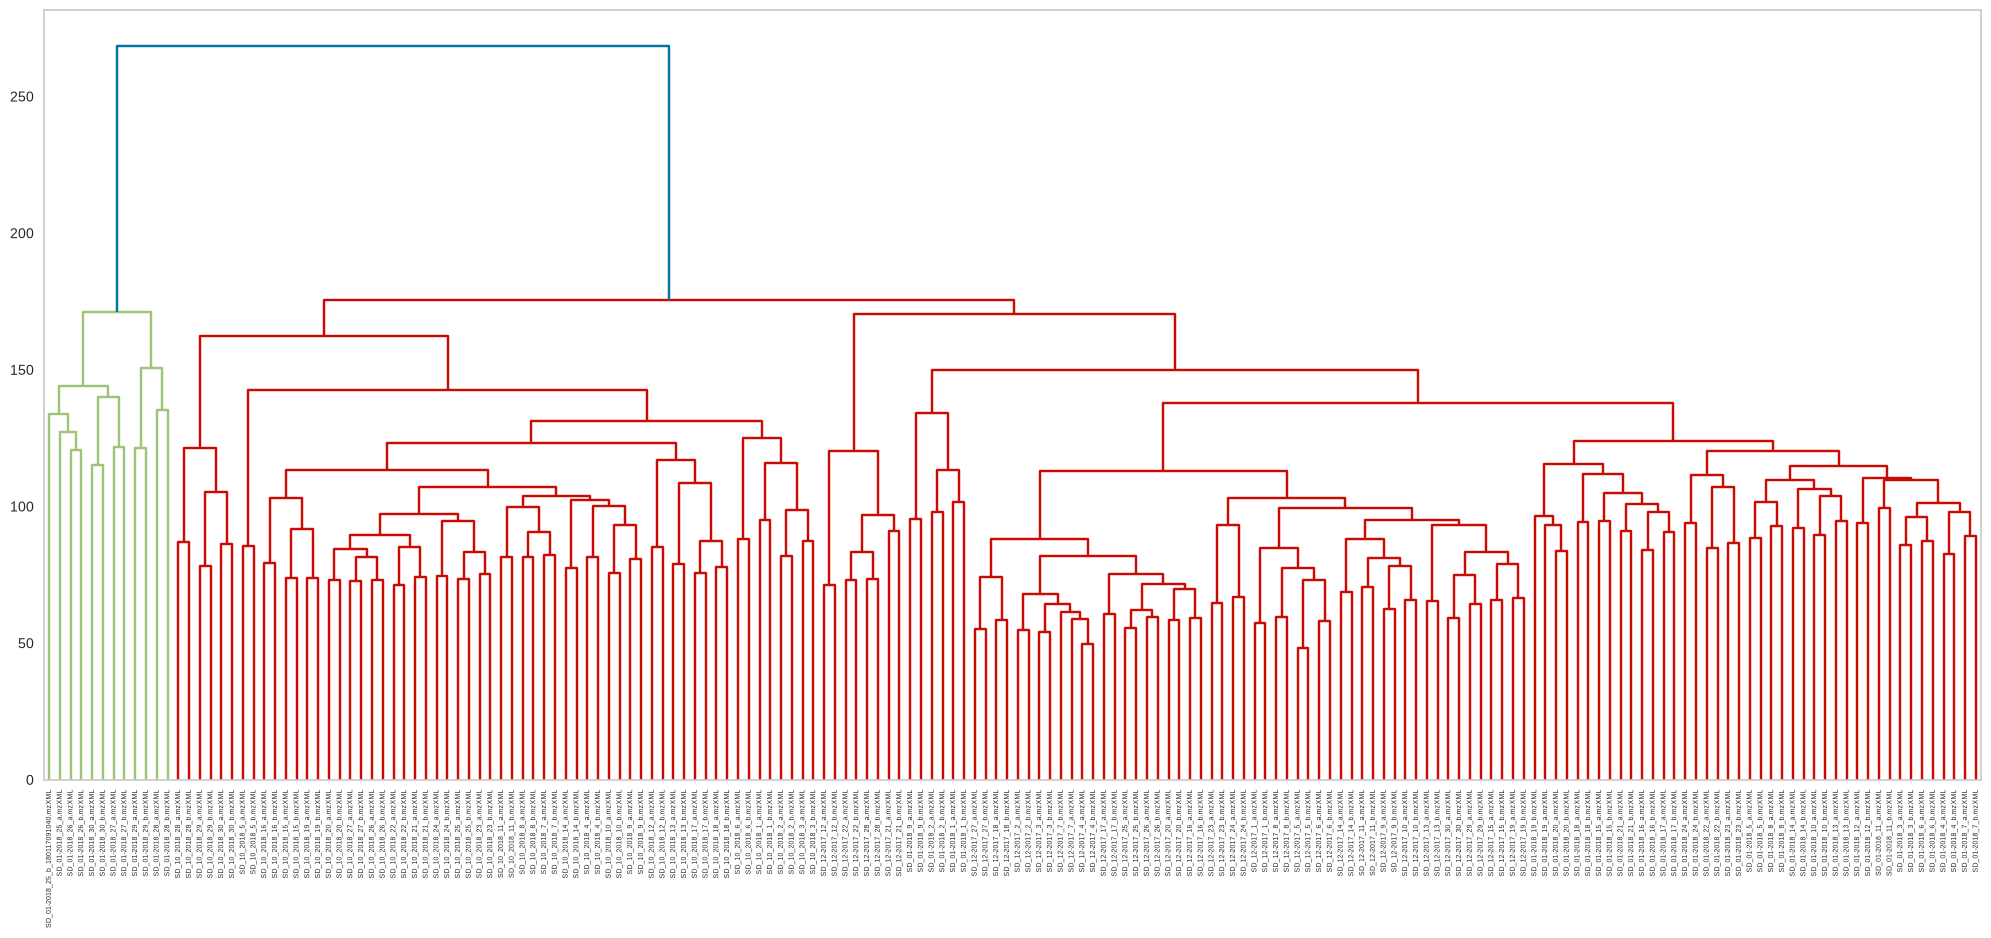

In [ ]:
np.random.seed(1234) # Setting a seed for reproducing the same result

linkage_data = linkage(cleaned_data, method='complete', metric='euclidean')
dendrogram(linkage_data, labels=cleaned_data.index)

plt.grid(False)
plt.show()

Once HCA is completed, a dendrogram is generated. This dendrogram shows split or merge distances as ‘height’ along the y-axis, providing a visual representation of the cluster formation.

### <font color ='darkblue'> Cutting the Dendrogram </font>

You can also cut the dendrogram to create the desired number of clusters. In this case, it seems we have 3 main 'splits', further divided into a total of 4 clusters.

<font color = "red" size = 4> For your own dataset, you can customize the number of clusters by specifying the desired value in the `p` parameter in the cell below, as `p=your_desired_value`</font>

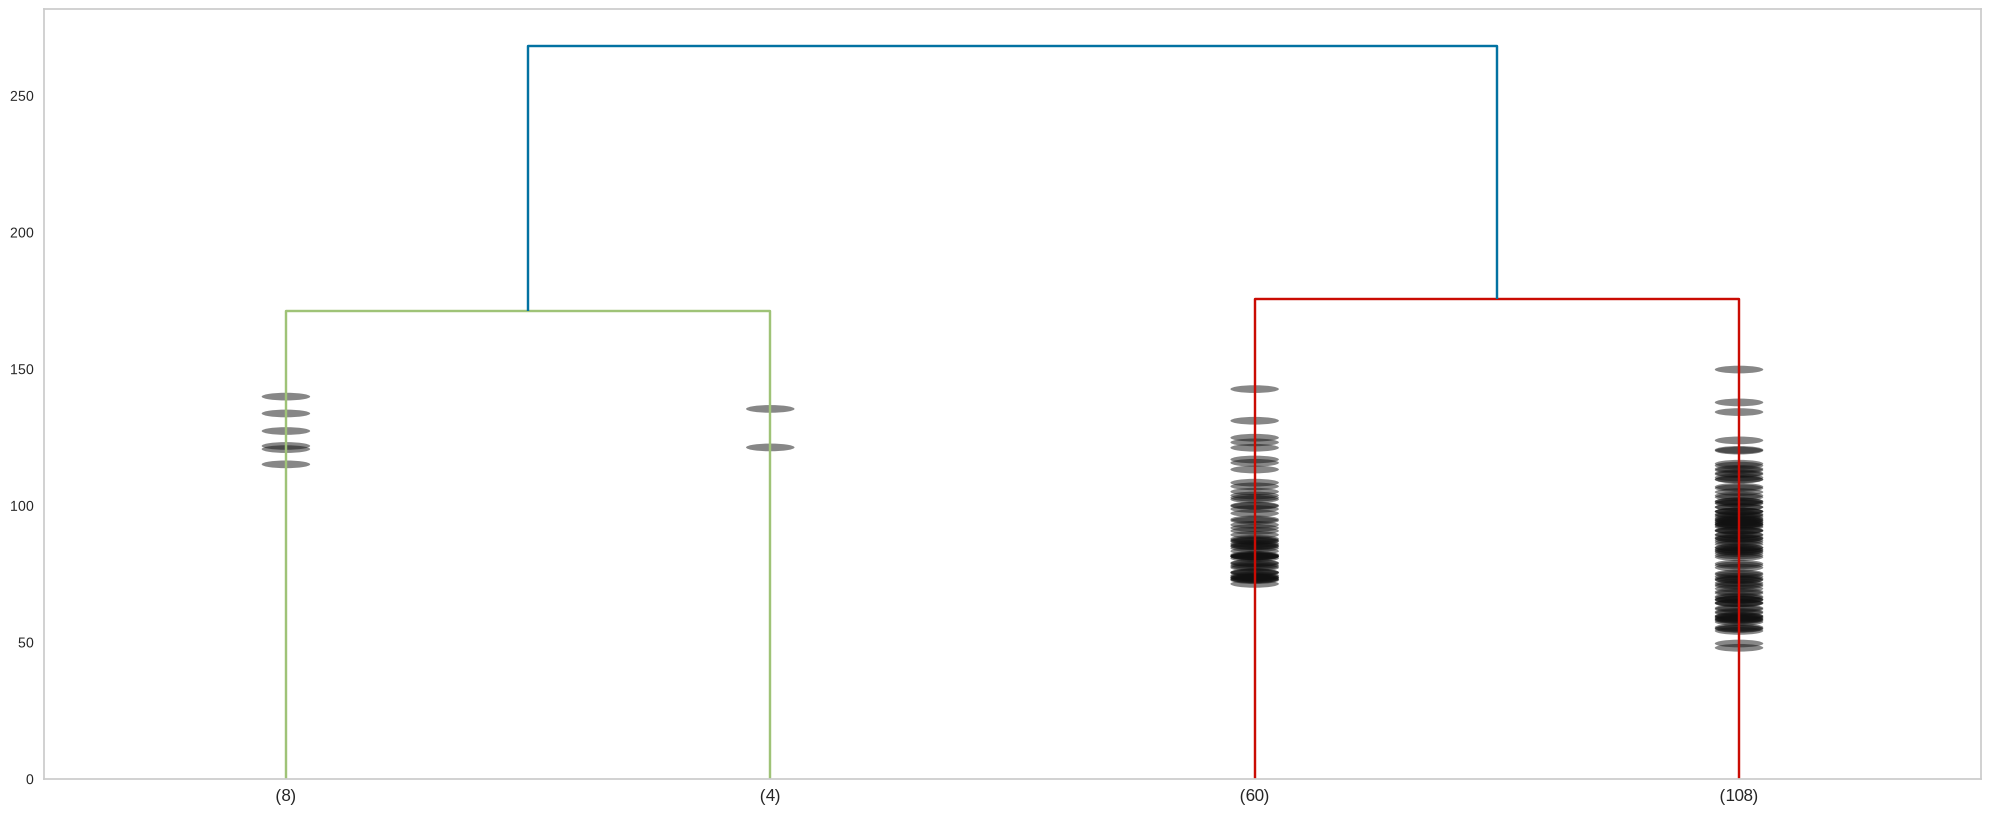

In [ ]:
clustering = dendrogram(linkage_data, truncate_mode='lastp', p=4, show_contracted=True)
plt.grid(False)
plt.show()

The values displayed on the x-axis indicate the number of samples within each cluster. To extract the labels from the clustering result and save them as a CSV file, you can execute the following code:

In [ ]:
cluster_labels = fcluster(linkage_data, t=4, criterion='maxclust')

# Pair these cluster labels with original labels (which are in cleaned_data.index)
label_cluster_pairs = list(zip(cleaned_data.index, cluster_labels))
cluster_results = pd.DataFrame(label_cluster_pairs, columns=['Sample Name', 'Assigned Cluster'])

# View or save to CSV
print(cluster_results)

#save the file
cluster_results.to_csv("hierarchichal_cluster_labels.csv")

               Sample Name  Assigned Cluster
0    SD_01-2018_10_a.mzXML                 4
1    SD_01-2018_10_b.mzXML                 4
2    SD_01-2018_11_a.mzXML                 4
3    SD_01-2018_11_b.mzXML                 4
4    SD_01-2018_12_a.mzXML                 4
..                     ...               ...
175   SD_12-2017_7_b.mzXML                 4
176   SD_12-2017_8_a.mzXML                 4
177   SD_12-2017_8_b.mzXML                 4
178   SD_12-2017_9_a.mzXML                 4
179   SD_12-2017_9_b.mzXML                 4

[180 rows x 2 columns]


### <font color ='darkblue'> Coloring the Dendrogram </font>

Finally, we can extract the cluster allocation information and color the dendrogram according to the clusters. For our data, the dendrogram suggests two main splits, resulting in four distinct clusters.

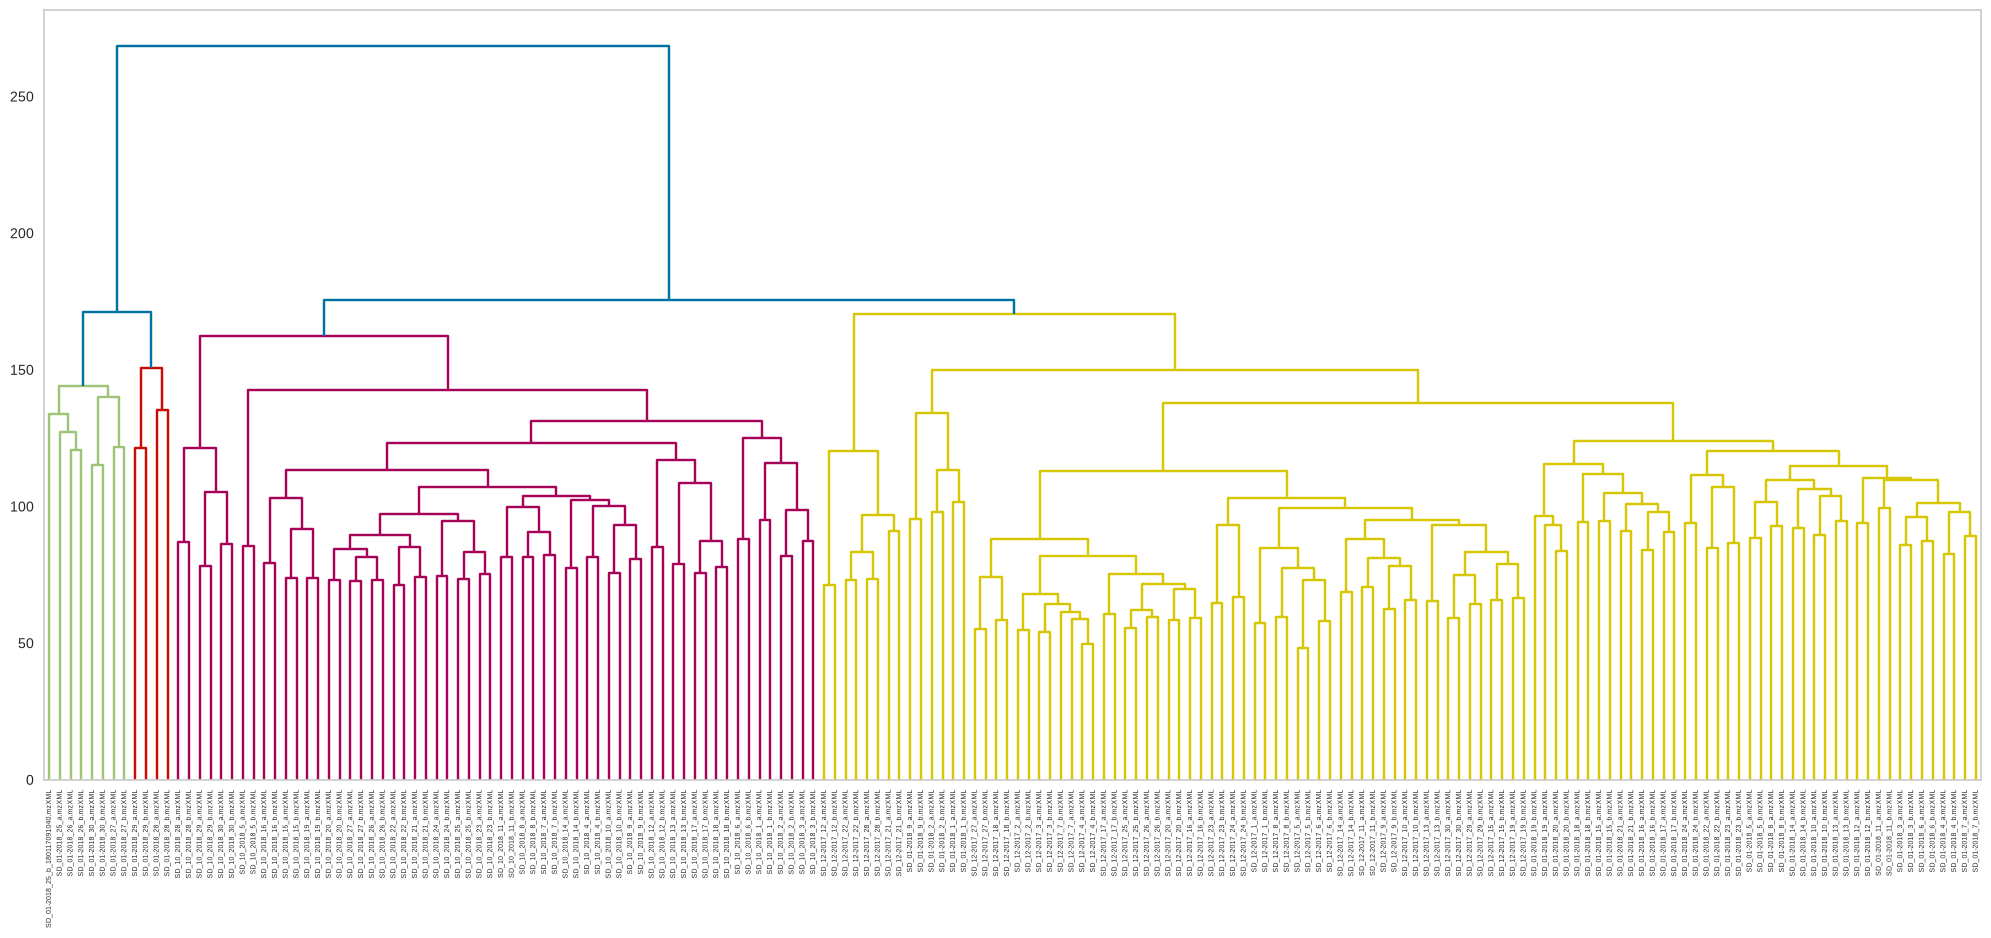

In [ ]:
# Get the y-axis level corresponding to 4 clusters
clust_array = np.array(clustering['dcoord'])
clust_threshold = np.floor(np.min(clust_array[np.nonzero(clust_array)]))

# Plot the dendrogram with the 4 clusters coloured
tmp = dendrogram(linkage_data, color_threshold=clust_threshold, labels=cleaned_data.index)
plt.grid(False)

plt.savefig(f"colored_dendrogram.svg", format="svg")
plt.show()

### <font color ='darkblue'> Determining the Optimal Number of Clusters </font>

We can define the number of clusters using some simple approaches. We will look at two methods here: (i) the Elbow approach and (ii) the average silhouette method. The **Elbow method** looks at the total within-cluster sum of square (WSS) as a function of the number of clusters. <br>
WSS: sum of distances between the points and the corresponding centroids for each cluster.

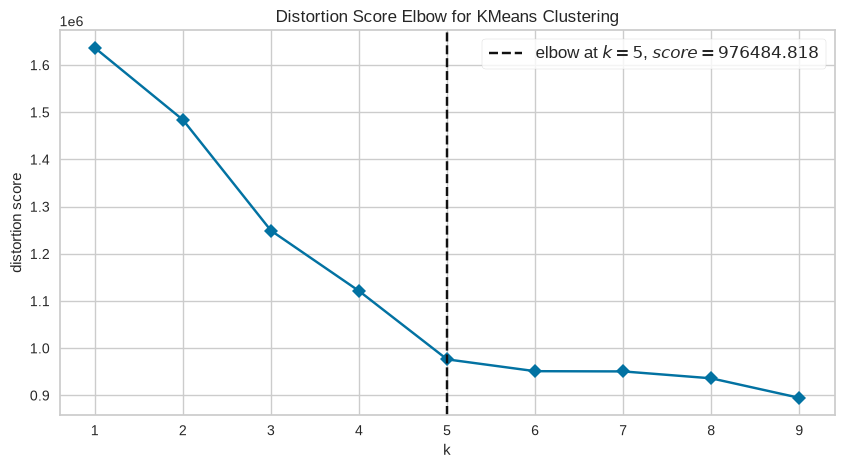

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
plt.rcParams["figure.figsize"] = [10, 5] # adjusting the plot size

# Elbow method

# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10), timings=False)

visualizer.fit(cleaned_data)
visualizer.finalize() # Finalize the figure for rendering

plt.savefig(f"elbow_plot.svg", format="svg") # Save the figure using Matplotlib's savefig

visualizer.show()

The location of an 'elbow' in the plot is usually considered as an indicator of the appropriate number of clusters because it means that adding another cluster does not improve the grouping. This method seems to suggest 4 clusters `elbow at k=4`. The Elbow method is sometimes ambiguous. An alternative to this is the **average silhouette method**. The Silhouette method measures the quality of a clustering and determines how well each point lies within its cluster.

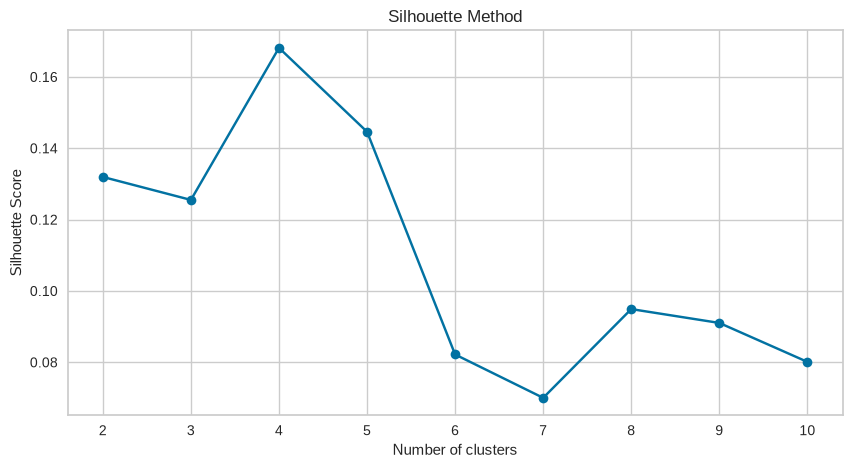

In [ ]:
# Silhouette method
silhouette_scores = []

for i in range(2,11):
  km = KMeans(n_clusters=i, random_state=42)
  km.fit_predict(cleaned_data)
  silhouette_scores.append(silhouette_score(cleaned_data, km.labels_))

plt.plot(range(2,11), silhouette_scores,  marker='o')
plt.title('Silhouette Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')

plt.savefig(f"sihouette_plot.svg", format="svg") # Save the figure

plt.show()

<p style='text-align: justify;'> In this case, the silouette method seems to find 2 main clusters (maximal value). There are several other methods to discover the optimal number of clusters and sometimes they do not fully agree. Often, you will need to bring your own knowledge about the specific field to decide whether the number of clusters makes sense. </p>

---
## Heatmaps
<a name="heat_maps"></a>

<p style='text-align: justify;'>In the next section we will add an additional layer in our visualization by plotting a heatmap together with the hierarchical clustering. First, we prepare the <b>'decoration'</b> for our heatmap. We want to show some of the metadata such as 'ATTRIBUTE_Month', 'ATTRIBUTE_Year'and 'ATTRIBUTE_Sample_Area' colored in a distinctive way. It is much easier to read the heatmap in this way. For this, we are going to use the <a href="https://dingwb.github.io/PyComplexHeatmap/build/html/index.html">PyComplexHeatmap package</a></p>

### <font color ='darkblue'> Preparing Metadata for Heatmap </font>

<p style='text-align: justify;'> <font color = 'red' size=4> For your own dataset, define the metadata attributes accordingly in the next cell. </font> <b> In our case, we specified the following attributes: 'ATTRIBUTE_Month', 'ATTRIBUTE_Year' and 'ATTRIBUTE_Sample_Area'. </b> These three columns were used to indicate clustering at the top of the heatmap. You can select any number of columns from your metadata as you see fit for the heatmap. Upon running the next cell, you'll be prompted to "Enter the index number of the attributes for Heatmap separated by commas." Simply input the desired indices. </p>

In [ ]:
display(InsideLevels(new_md.iloc[:, 1:]))
#input_str = input('Enter the index number of the attributes for Heatmap separated by commas: ')

,ATTRIBUTES,LEVELS,COUNT,TYPES
1,ATTRIBUTE_Sample_Type,"[Blank, Sample]","[6, 180]",<class 'str'>
2,ATTRIBUTE_Batch,"[1, 2, 3]","[62, 62, 62]",<class 'numpy.int64'>
3,ATTRIBUTE_Month,"[Dec, Jan, Oct]","[62, 62, 62]",<class 'str'>
4,ATTRIBUTE_Year,"[2017, 2018]","[62, 124]",<class 'numpy.int64'>
5,ATTRIBUTE_Sample_Location,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...",<class 'numpy.int64'>
6,ATTRIBUTE_Replicate,"[a, b]","[93, 93]",<class 'str'>
7,ATTRIBUTE_Spot,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...",<class 'numpy.int64'>
8,ATTRIBUTE_Latitude,"[32.75645, 32.75743, 32.75905, 32.76115, 32.76...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...",<class 'numpy.float64'>
9,ATTRIBUTE_Longitude,"[-117.2872, -117.28664, -117.286, -117.28355, ...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, ...",<class 'numpy.float64'>
10,ATTRIBUTE_Sample_Area,"[Blank, La_Jolla Reefs, La_Jolla_Cove, Mission...","[6, 36, 12, 36, 18, 12, 18, 48]",<class 'str'>


In [ ]:
input_list = [3, 4, 10]

In [ ]:
heatmap_attributes = list(InsideLevels(new_md).iloc[input_list]['ATTRIBUTES'])
ann = metadata.loc[:,heatmap_attributes]
ann.columns = ann.columns.str.replace('ATTRIBUTE_','') #removing the ATTRBUTE suffix from column names for easier heatmap visualization
heatmap_attributes = [attr.replace('ATTRIBUTE_','') for attr in heatmap_attributes]

### <font color ='darkblue'> Generating annotations for Heatmap </font>

In this step, we construct a data frame using the selected metadata, assigning individual colors for clear differentiation. Assign this data frame to annotate the heatmap using ‘HeatmapAnnotation’ function from the ‘PyComplexHeatmap’ package. </br>

Explore more colors using the [Matplotlib colormaps](https://matplotlib.org/stable/tutorials/colors/colormaps.html) or by simply check for the hex code https://www.color-hex.com/

<font color="green" size=4> The following cell is a function block to assign the colors from the 'custom palette' to each unique level of the chosen attributes for heatmap visualization</font>.

In [ ]:
def generate_colors(attributes):
  colors = {}
  for attribute in attributes:
    unique_levels = list(set(ann.loc[:,attribute]))
    n_colors = len(unique_levels)
    selected_colors = custom_palette[:n_colors]
    colors_levels = {unique_levels[i]: selected_colors[i] for i in range(n_colors)}
    colors[attribute] = colors_levels
  return(colors)

In [ ]:
colors = generate_colors(heatmap_attributes)
display(colors)

{'Month': {'Oct': 'orange', 'Dec': 'green', 'Jan': 'red'},
 'Year': {2017: 'orange', 2018: 'green'},
 'Sample_Area': {'Torrey_Pines': 'orange',
  'Pacific_Beach': 'green',
  'SIO_La_Jolla_Shores': 'red',
  'Mission_Bay': 'blue',
  'Mission_Beach': 'black',
  'La_Jolla Reefs': 'slategray',
  'La_Jolla_Cove': 'purple'}}

In [ ]:
col_ha = HeatmapAnnotation(df=ann, colors=colors, verbose=0)

### <font color ='darkblue'> Creating the Heatmap </font>

[PyComplexHeatmap](https://github.com/DingWB/PyComplexHeatmap) gives you a flexible function and it is easy to change parameters. In the following, we will perform hierarchical clustering based on Euclidean distance.

<p style='text-align: justify;'><font color = 'red'> As we said, Euclidean distance is just an example that fits well with the continuous numerical values in your dataset but there are several distance measures such as Cityblock (Manhattan), Minkowski, Canberra etc. If you have binary data, you may consider to use Jaccard distance. </font></p>

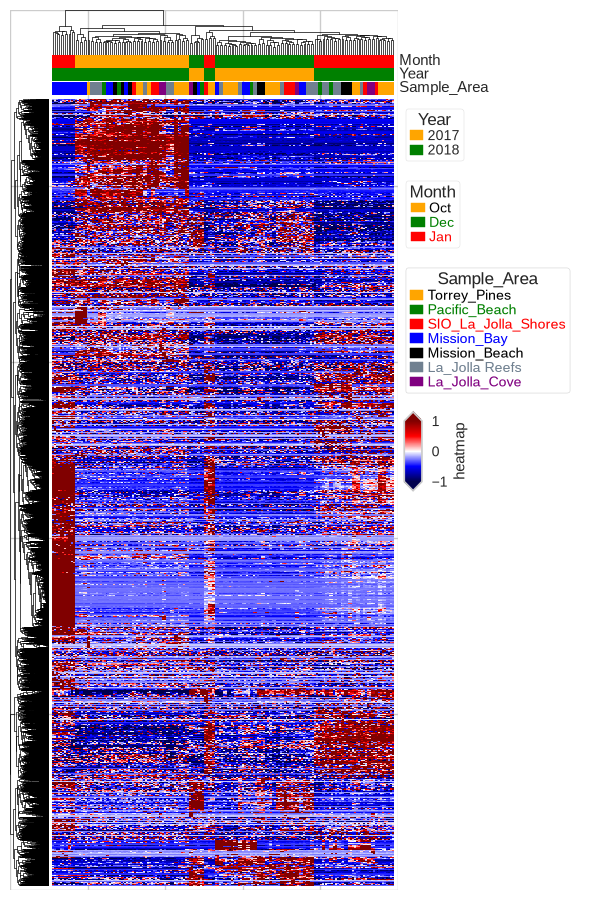

In [ ]:
np.random.seed(1234) # Setting a seed for reproducing the same result

fig = plt.figure(figsize=(5, 10))
cm = ClusterMapPlotter(data=cleaned_data.T, #heatmap_data.T,
                       top_annotation=col_ha,
                       col_dendrogram=True,
                       col_cluster_method='complete',
                       col_cluster_metric='euclidean', # you can change the distance here
                       row_dendrogram=True,
                       row_cluster_method='complete',
                       row_cluster_metric='euclidean', # you can change the distance here
                       cmap='seismic',
                       vmin=-1,  # Set minimum value for colormap
                       vmax=1,  # Set maximum value for colormap
                       verbose=0)

fig.savefig(f"Heatmap_plot.svg", format="svg")

As we can see, by using this type of visualization we can clearly observe the similarities between samples and features, in particular we can see again the separation of samples retrieved in 2017 and 2018 and separation based on month.

While the color map's original range spans from around -6 to 14, we've set the color limits manually to -1 and +1 using the vmin and vmax parameters. This adjustment provides a clearer distinction in the heatmap, as all values below -1 appear uniformly blue, and those above +1 are uniformly red. You can opt to use the default color range by omitting these parameters or specify your own for different visual insights.

We can also apply a method for dividing the heatmap according to a cluster assignment, similarly to step 36, for generating better visualizations that can help the interpretation of the results.

# <font color = 'blue'> Supervised learning with Random Forest</font>
<a name="rf"></a>

<p style='text-align: justify;'> Random Forest is a powerful machine learning algorithm used for both classification and regression tasks. It is an ensemble learning method that combines multiple decision trees to improve the accuracy and robustness of the model. Each tree in the forest is constructed using a random subset of features and training data, which helps to reduce overfitting and increase the diversity of the trees. Random Forest can handle multidimensional data with complex interactions and provides feature importance measures, making it a popular choice for many applications in various fields. </p>

### <font color ='darkblue'>Prepare the data for Random Forest </font>

In [ ]:
# merging metadata with cleaned data
cleaned_data_with_md = metadata.merge(cleaned_data, left_index=True, right_index=True, how="inner")

In [ ]:
cleaned_data_with_md.to_csv("Cleaned_table_with_metadata.csv") # save to file

In [ ]:
# to merge metadata with a particular dataframe, for example, normalised data:
md_Norm_merged = metadata.merge(norm_TIC, left_index=True, right_index=True, how="inner")

In [ ]:
md_Norm_merged.to_csv(os.path.join(data_dir, "NormTIC_metadata_merged.csv")) # save to file

We make sure that the merging of the two data frames was successful.

In [ ]:
print('Dimensions cleaned data: ', cleaned_data.shape)
print('Dimensions metadata: ', metadata.shape)
print('Dimensions cleaned data merged with metadata: ', cleaned_data_with_md.shape)

Dimensions cleaned data:  (180, 9092)
Dimensions metadata:  (180, 13)
Dimensions cleaned data merged with metadata:  (180, 9105)


In [ ]:
cleaned_data_with_md.head()

,ATTRIBUTE_Sample_Type,ATTRIBUTE_Batch,ATTRIBUTE_Month,ATTRIBUTE_Year,ATTRIBUTE_Sample_Location,ATTRIBUTE_Replicate,ATTRIBUTE_Spot,ATTRIBUTE_Latitude,ATTRIBUTE_Longitude,ATTRIBUTE_Sample_Area,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,Sample,2,Jan,2018,10,a,10,32.86261,-117.26042,SIO_La_Jolla_Shores,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,Sample,2,Jan,2018,10,b,10,32.86261,-117.26042,SIO_La_Jolla_Shores,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224
SD_01-2018_11_a.mzXML,Sample,2,Jan,2018,11,a,11,32.85601,-117.26253,SIO_La_Jolla_Shores,...,-0.251313,-0.307305,-1.541638,0.097061,-0.383222,-0.421790,-0.250336,-0.114446,-0.113095,-0.392102
SD_01-2018_11_b.mzXML,Sample,2,Jan,2018,11,b,11,32.85601,-117.26253,SIO_La_Jolla_Shores,...,-0.396538,-0.310075,-1.220736,-0.301133,-0.424088,-0.409242,-0.345876,0.171960,-0.279472,-0.353041
SD_01-2018_12_a.mzXML,Sample,2,Jan,2018,12,a,12,32.85161,-117.26965,La_Jolla_Cove,...,-0.425236,-0.305349,-0.228593,-0.373532,-0.428446,-0.480693,-0.629134,-0.088028,-0.234043,-0.403290


### <font color ='darkblue'>Select the Classification Attribute for Random Forest </font>

In [ ]:
rf_data = cleaned_data_with_md.copy()

#InsideLevels(rf_data.iloc[:, 1:].filter(regex='^(?!X)'))

<font color="red" size=4>In the cell below, enter the name of interested attribute to use for the classification. </font>
Here, we want to see how RF classifies the samples according to different sample area **(ATTRIBUTE_Sample_Area)**.

In [ ]:
interested_attr = 'ATTRIBUTE_Sample_Area'

For the RF classification we need to transform the strings to numericals using the OrdinalEncoder.

In [ ]:
# Change the values of the attribute of interest from strings to a numerical
enc = OrdinalEncoder()
labels = rf_data[[interested_attr]]
display(labels.value_counts()) # Displays the sample size for each group
labels = enc.fit_transform(labels)
labels = np.array([x[0] + 1 for x in labels])

ATTRIBUTE_Sample_Area
Torrey_Pines             48
La_Jolla Reefs           36
Mission_Bay              36
SIO_La_Jolla_Shores      18
Mission_Beach            18
La_Jolla_Cove            12
Pacific_Beach            12
Name: count, dtype: int64

In [ ]:
# Extract the features (columns starting with X) and their column names
features = rf_data.filter(regex='^X')
feature_names = features.columns.values.tolist()
print(features.shape)
display(features.head())

(180, 9092)


,X2_161.096_0.235_nan;Massbank:LU096701 4-Methylumbelliferone|7-hydroxy-4-methylchromen-2-one,X4_167.154_0.474_,"X11_172.956_0.487_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X15_289.168_0.501_,X16_291.165_0.501_,X17_453.234_0.503_,X19_451.237_0.503_,X21_534.268_0.503_,X35_192.062_0.547_,X39_153.033_0.55_,...,X92572_151.035_13.364_,X92576_311.185_13.406_nan;2'-Hydroxy-a-naphthoflavone CollisionEnergy:102040,"X92582_172.956_13.395_nan;""6-methoxypurine, oxamethane CollisionEnergy:102040""",X92588_294.206_13.508_,X92596_322.237_13.562_,X92603_322.237_13.768_,X92606_172.956_13.801_,X92610_184.985_13.892_nan;4-((hydroxyimino)methyl)-1-methylhydroquinolin-2-one CollisionEnergy:102040,X92619_264.144_14.118_,"X92651_172.956_14.611_nan;""6-methoxypurine, oxamethane CollisionEnergy:205060"""
SD_01-2018_10_a.mzXML,-0.342852,-0.594422,0.770878,-0.698076,-0.688803,-0.544895,-0.545050,-0.579735,0.964910,0.498183,...,-0.142612,-0.305189,-0.244244,-0.067403,0.700786,0.922444,0.400949,-0.068666,-0.117481,-0.378166
SD_01-2018_10_b.mzXML,-0.327681,-0.594734,0.950660,-0.707899,-0.666675,-0.558067,-0.601093,-0.587369,2.198253,1.300497,...,-0.083043,-0.309351,-0.424738,0.372585,0.057133,0.675513,0.593040,-0.102960,-0.135823,-0.299224
SD_01-2018_11_a.mzXML,-0.314556,-0.595108,0.550822,-0.229065,-0.214096,-0.593805,-0.538419,-0.594442,0.640314,-0.080669,...,-0.251313,-0.307305,-1.541638,0.097061,-0.383222,-0.421790,-0.250336,-0.114446,-0.113095,-0.392102
SD_01-2018_11_b.mzXML,-0.331714,-0.616160,0.734658,-0.657409,-0.650143,-0.595647,-0.528789,-0.563008,0.347893,-0.180115,...,-0.396538,-0.310075,-1.220736,-0.301133,-0.424088,-0.409242,-0.345876,0.171960,-0.279472,-0.353041
SD_01-2018_12_a.mzXML,-0.323948,-0.612324,0.596451,-0.503381,-0.551075,-0.551527,-0.497215,-0.574347,0.892233,0.792508,...,-0.425236,-0.305349,-0.228593,-0.373532,-0.428446,-0.480693,-0.629134,-0.088028,-0.234043,-0.403290


Generate a training and test set for the RF classification.

In [ ]:
# Split the data into training and test sets
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.25, random_state=123)

print('Training Features Shape:', train_features.shape)
print('Training Labels Shape:', train_labels.shape)
print('Testing Features Shape:', test_features.shape)
print('Testing Labels Shape:', test_labels.shape)

Training Features Shape: (135, 9092)
Training Labels Shape: (135,)
Testing Features Shape: (45, 9092)
Testing Labels Shape: (45,)


### <font color ='darkblue'> Balance sample sizes </font>
The sample size is different among the groups (see above). We therefore need to balance the size.

In [ ]:
# Balance the weights of the attribute of interest to account for unbalanced sample sizes per group
sklearn_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels)
weights = {}
for i,w in enumerate(np.unique(train_labels)):
  weights[w] = sklearn_weights[i]
print(weights)

{np.float64(1.0): np.float64(0.7142857142857143), np.float64(2.0): np.float64(1.7532467532467533), np.float64(3.0): np.float64(0.8385093167701864), np.float64(4.0): np.float64(1.4835164835164836), np.float64(5.0): np.float64(1.7532467532467533), np.float64(6.0): np.float64(1.3775510204081634), np.float64(7.0): np.float64(0.5357142857142857)}


### <font color ='darkblue'> Step 54: Run Random Forest </font>

<p style='text-align: justify;'> Performing Random Forest with 500 trees (n_estimators). Generally, a larger number of this variable improves the performance of the model but also increases the computational cost. It is recommended to start with a reasonable number of trees (e.g., 500-1000) and then tune it based on the performance. </p>

<font color="red"><font size=3> Depending on the number of trees provided, the following cell may take a considerable amount of time to execute !!</font>

In [ ]:
# Set up the random forest classifier with 500 tress, balanced weights, and a random state to make it reproducible
rf = RandomForestClassifier(n_estimators=500, class_weight=weights, random_state=123)
# Fit the classifier to the training set
rf.fit(train_features, train_labels)

RandomForestClassifier(class_weight={np.float64(1.0): np.float64(0.7142857142857143),
                                     np.float64(2.0): np.float64(1.7532467532467533),
                                     np.float64(3.0): np.float64(0.8385093167701864),
                                     np.float64(4.0): np.float64(1.4835164835164836),
                                     np.float64(5.0): np.float64(1.7532467532467533),
                                     np.float64(6.0): np.float64(1.3775510204081634),
                                     np.float64(7.0): np.float64(0.5357142857142857)},
                       n_estimators=500, random_state=123)

In [ ]:
# Use the random forest classifier to predict the sample areas in the test set
predictions = rf.predict(test_features)
print('Classifier mean accuracy score:', round(rf.score(test_features, test_labels)*100, 2), '%.')

Classifier mean accuracy score: 86.67 %.


In [ ]:
# Report of the accuracy of predictions on the test set
print(classification_report(test_labels, predictions))
# Print the sample areas corresponding to the numbers in the report
for i,cat in enumerate(enc.categories_[0]):
  print(i+1.0, cat)

              precision    recall  f1-score   support

         1.0       0.75      1.00      0.86         9
         2.0       1.00      1.00      1.00         1
         3.0       0.93      1.00      0.96        13
         4.0       1.00      0.60      0.75         5
         5.0       0.00      0.00      0.00         1
         6.0       1.00      0.25      0.40         4
         7.0       0.86      1.00      0.92        12

    accuracy                           0.87        45
   macro avg       0.79      0.69      0.70        45
weighted avg       0.87      0.87      0.84        45

1.0 La_Jolla Reefs
2.0 La_Jolla_Cove
3.0 Mission_Bay
4.0 Mission_Beach
5.0 Pacific_Beach
6.0 SIO_La_Jolla_Shores
7.0 Torrey_Pines


### <font color ='darkblue'>Evaluate model performance </font>

<p style='text-align: justify;'>In Random Forest, the OOB (Out-Of-Bag) error is an estimate of the model's prediction error on unseen data. During the training process, each tree in the forest is grown using a bootstrap sample of the original data, leaving out about one-third of the observations on average. These left-out observations are called the OOB samples. The OOB error line in Random Forest provides an estimate of the model's error rate based on the OOB samples. It is a useful metric for evaluating the performance of the model and for comparing different random forest models. A lower OOB error indicates better predictive performance, but it is important to validate the model on a separate test set to obtain a more accurate estimate of its performance on new data. </p>

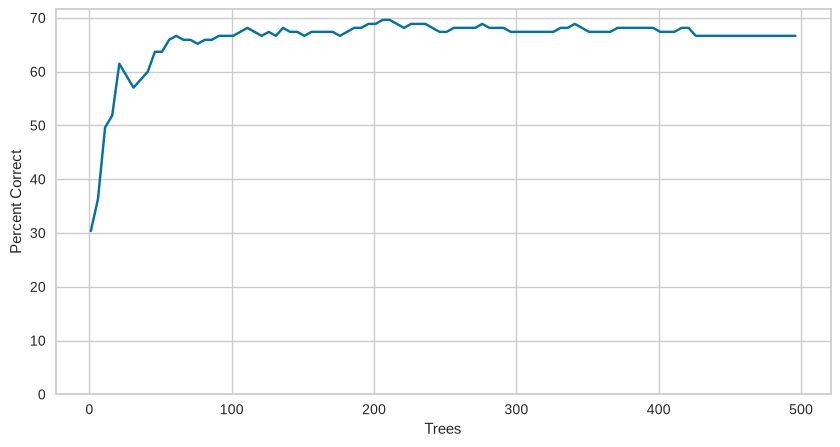

In [ ]:
# Most important model quality plot
# OOB error lines should flatline. If it doesn't flatline add more trees
rf = RandomForestClassifier(class_weight=weights, warm_start=True, oob_score=True, random_state=123)
errors = []
tree_range = np.arange(1,500,5)
for i in tree_range:
  rf.set_params(n_estimators=i)
  rf.fit(train_features, train_labels)
  errors.append(rf.oob_score_*100)

plt.plot(tree_range, errors)
plt.ylim(0)
plt.xlabel("Trees")
plt.ylabel("Percent Correct")
plt.savefig(f"OOB_curve.svg", format="svg")
plt.show()

### <font color ='darkblue'>Interpreting RF Results </font>

**Ranking features by Mean Decrease Accuracy**:

The random forest model provides a feature importance metric known as "Mean Decrease Impurity". Here, higher importance means the feature significantly influenced the prediction classes, in our case, the prediction of the sampling area. However, this metric can be biased towards features with more categories. A more unbiased measure is "Mean Decrease Accuracy" (MDA). MDA evaluates the impact on model's performance when a feature's value is shuffled. If the model accuracy drops significantly, the feature is deemed important. This concept is executed through `permutation_importance` offered by scikit-learn. More details can be found here: https://scikit-learn.org/stable/modules/permutation_importance.html.

In [ ]:
feature_names = features.columns.tolist() #getting all the column names of features to a list
feature_importance_dict = dict(zip(feature_names, rf.feature_importances_)) #creating a dictionary

<p style='text-align: justify;'> <font color = 'red' size = 4> Depending on the number of permutations (<code>n_repeats</code>) provided, the following cell may take a considerable amount of time to execute !! </font> We have set <code>n_repeats=10</code> to shuffle the data 10 times, and we have fixed <code>random_state=0</code> to ensure reproducibility of our permutation results. Given our large dataset of 180 samples with 9,092 features each, using <code>n_repeats=10</code> is already computation-intensive. If your dataset is smaller, you could consider increasing this up to <code>n_repeats=30</code>. </p>

In [ ]:
# Record the start time
start_time = time.time()

# Perform permutation importance
rf_result = permutation_importance(rf,
                                   test_features,
                                   test_labels,
                                   n_repeats=10, #change n_repeats value here as desired
                                   random_state=0)

mean_decrease_accuracy =rf_result.importances_mean
std_decrease_accuracy = rf_result.importances_std

# To map these values back to feature names:
mean_decrease_accuracy_dict = dict(zip(feature_names, mean_decrease_accuracy))
std_decrease_accuracy_dict = dict(zip(feature_names, std_decrease_accuracy))

# Calculate and display the time taken
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.2f} seconds")

In [ ]:
# Convert dictionaries to DataFrames
feature_importance_df = pd.DataFrame(list(feature_importance_dict.items()), columns=['Feature', 'Importance'])
mean_decrease_accuracy_df = pd.DataFrame(list(mean_decrease_accuracy_dict.items()), columns=['Feature', 'Mean Decrease Accuracy'])
std_decrease_accuracy_df = pd.DataFrame(list(std_decrease_accuracy_dict.items()), columns=['Feature', 'Std Decrease Accuracy'])

# Merge the DataFrames
importance_df = pd.merge(feature_importance_df, mean_decrease_accuracy_df, on='Feature')
importance_df = pd.merge(importance_df, std_decrease_accuracy_df, on='Feature')

# Sort the DataFrame if needed
importance_df = importance_df.sort_values(by='Mean Decrease Accuracy', ascending=False)
importance_df.head()

In [ ]:
# Save the features and their importance
importance_df.to_csv('Importance_features_RF_500trees.csv')